#  Projeto de previsão de Aluguel utilizando Regressão Polinomial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Carregando DataFrame
df_imoveis = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

In [ ]:
# Visualiando DataFrame
df_imoveis.head()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


In [ ]:
# Dividindo variavel Base de Aluguel
y = df_imoveis['Valor_Aluguel']

In [ ]:
# Dividindo variavel Target para utilizar na previsisao
x = df_imoveis['Metragem']

In [ ]:
# Realizando processamento dos dados utilizando Polynomial Feature
poly_features = PolynomialFeatures(degree=2)

In [ ]:
x_poly = poly_features.fit_transform(x.values.reshape(-1, 1))

In [ ]:
x_poly

array([[1.0000e+00, 4.8000e+01, 2.3040e+03],
       [1.0000e+00, 5.0000e+01, 2.5000e+03],
       [1.0000e+00, 4.0000e+01, 1.6000e+03],
       ...,
       [1.0000e+00, 2.6600e+02, 7.0756e+04],
       [1.0000e+00, 6.0000e+02, 3.6000e+05],
       [1.0000e+00, 2.4800e+02, 6.1504e+04]])

In [ ]:
# Separando os dados
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

In [ ]:
# Aplicando regressão linear nos dados transformados
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
print("Tamanho de x_test:", x_test.shape)
print("Tamanho de y_test:", y_test.shape)

Tamanho de x_test: (1441, 3)
Tamanho de y_test: (1441,)


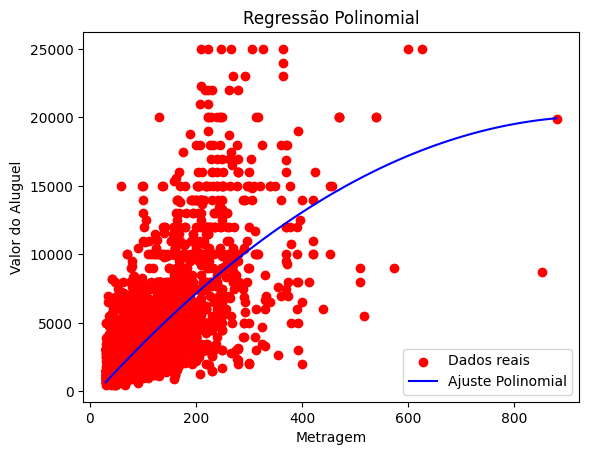

In [ ]:
# Plotando grafico da Regressao
y_pred = model.predict(x_test)

# Criaremos uma sequência de valores X para a visualização, buscando a suavização
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
x_range_poly = poly_features.transform(x_range)
y_range_pred = model.predict(x_range_poly)

plt.scatter(x, y, color='red', label='Dados reais')  # Dados reais
plt.plot(x_range, y_range_pred, color='blue', label='Ajuste Polinomial')  # Linha do ajuste
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial')
plt.legend()
plt.show()

In [ ]:
# Avaliando o modelo
r2 = r2_score(y_test, y_pred)
print(f'R² da Regressão Polinomial: {r2:.4f}')

R² da Regressão Polinomial: 0.5423


In [ ]:
# Refazendo os passos anteriores utilizando o degree = 4
# Determinando o degree=4
poly_features = PolynomialFeatures(degree=4)

In [ ]:
x_poly = poly_features.fit_transform(x.values.reshape(-1, 1))

In [ ]:
# Separando a base de treino e teste
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

In [ ]:
# Aplicando regressão linear nos dados transformados
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
print("Tamanho de x_test:", x_test.shape)
print("Tamanho de y_test:", y_test.shape)

Tamanho de x_test: (1441, 5)
Tamanho de y_test: (1441,)


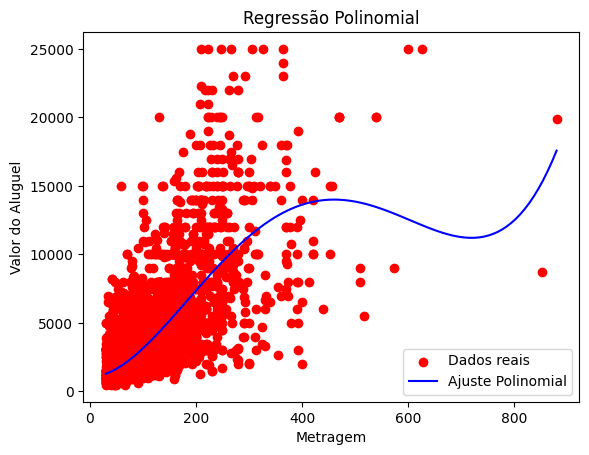

In [ ]:
# Plotando grafico da Regressao
y_pred = model.predict(x_test)

# Criaremos uma sequência de valores X para a visualização, buscando a suavização
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# Ensure poly_features is fitted before transformation for x_range
poly_features.fit(x.values.reshape(-1, 1))
x_range_poly = poly_features.transform(x_range)
y_range_pred = model.predict(x_range_poly)

plt.scatter(x, y, color='red', label='Dados reais')  # Dados reais
plt.plot(x_range, y_range_pred, color='blue', label='Ajuste Polinomial')  # Linha do ajuste
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial')
plt.legend()
plt.show()

In [ ]:
# Avaliando o novo modelo criado
r2 = r2_score(y_test, y_pred)
print(f'R² da Regressão Polinomial: {r2:.4f}')

R² da Regressão Polinomial: 0.5596


#Analisando os valores de R-quadrado dos dois modelos:
###• degree=2, o R² foi de 0.5423.
###• degree=4, o R² foi de 0.5596.

Embora os resultados sejam bastante próximos, o modelo com degree=4 mostra um valor de R² ligeiramente superior (0.5596) em comparação com o modelo com degree=2 (0.5423).

Isso indica um ajuste marginalmente melhor aos dados para o polinômio de grau superior.
Na regressão polinomial, aumentar o grau permite que o modelo capture relações não lineares mais complexas nos dados.
Para este conjunto de dados em particular, o aumento do R² de grau 2 para grau 4 é modesto, o que sugere que, embora possa haver alguma não linearidade que o grau 4 captura melhor, não é uma melhoria drástica.

##Sugestão a seguir para melhorias:
Para avaliar melhor se degree=4 é realmente superior e não está superajustado, você poderia considerar técnicas como validação cruzada para avaliar o desempenho do modelo em diferentes subconjuntos dos dados.